In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
train_path = "/content/drive/MyDrive/pr/final_dataset/train"
val_path = "/content/drive/MyDrive/pr/final_dataset/validation"
test_path = "/content/drive/MyDrive/pr/final_dataset/test"

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_gen = ImageDataGenerator(rescale=1./255)

In [5]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1750 images belonging to 5 classes.
Found 375 images belonging to 5 classes.
Found 375 images belonging to 5 classes.


In [6]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [7]:
print(train_data.class_indices)

{'dhoti': 0, 'frock': 1, 'salwar': 2, 'saree': 3, 'shirt': 4}


In [8]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Input(shape=(128,128,3)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(5, activation='softmax'))

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,669 (1.87 MB)

 Trainable params: 488,709 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [28]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 314ms/step - accuracy: 0.4571 - loss: 1.3246 - val_accuracy: 0.2000 - val_loss: 2.1225 - learning_rate: 2.7000e-05
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 306ms/step - accuracy: 0.4606 - loss: 1.3246 - val_accuracy: 0.2000 - val_loss: 2.0718 - learning_rate: 2.7000e-05
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 311ms/step - accuracy: 0.4617 - loss: 1.3148 - val_accuracy: 0.2053 - val_loss: 1.9789 - learning_rate: 2.7000e-05
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 326ms/step - accuracy: 0.4686 - loss: 1.3079 - val_accuracy: 0.2507 - val_loss: 1.7803 - learning_rate: 2.7000e-05
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 311ms/step - accuracy: 0.4863 - loss: 1.2805 - val_accuracy: 0.3200 - val_loss: 1.6274 - learning_rate: 2.7000e-05
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 306ms/step - accuracy: 0.4714 - loss: 1.2697 - val_accuracy: 0.4373 - val_loss: 1.3992 - learning_rate: 2.7000e-05
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 305ms/step - acc

In [29]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.5813 - loss: 1.0677
Validation Accuracy: 0.581333339214325


In [16]:
print(train_data.class_indices)

{'dhoti': 0, 'frock': 1, 'salwar': 2, 'saree': 3, 'shirt': 4}


In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

print(classification_report(y_true, y_pred_classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
              precision    recall  f1-score   support

           0       0.18      0.16      0.17        75
           1       0.29      0.27      0.28        75
           2       0.29      0.24      0.26        75
           3       0.24      0.29      0.26        75
           4       0.17      0.19      0.18        75

    accuracy                           0.23       375
   macro avg       0.23      0.23      0.23       375
weighted avg       0.23      0.23      0.23       375



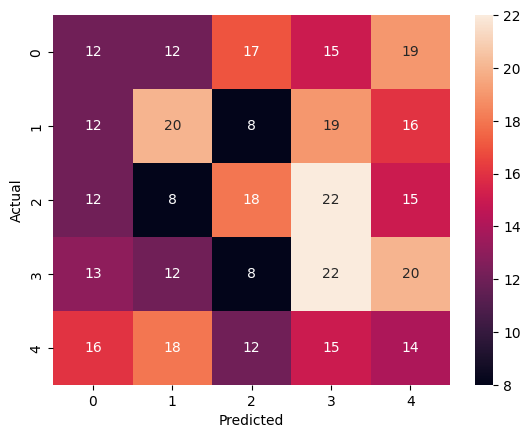

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
model.save("/content/drive/MyDrive/pr/dress_model.keras")

In [32]:
model.evaluate(val_data)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.5813 - loss: 1.0677


[1.0676701068878174, 0.581333339214325]

In [54]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

Saving 32b2420e4be4b3a6dd043ba0ec42f2d7.jpg to 32b2420e4be4b3a6dd043ba0ec42f2d7 (2).jpg


In [60]:
prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Dress Type:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Dress Type: saree
